<a href="https://colab.research.google.com/github/kawastony/Quantum_Gravity/blob/main/Paper_37_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import mpmath as mp

mp.mp.dps = 50

# -----------------------------
# Bessel functions and helpers
# -----------------------------

def J(nu, x):
    return mp.besselj(nu, x)

def Jprime(nu, x):
    # J'_\nu(x) = 1/2 (J_{\nu-1}(x) - J_{\nu+1}(x))
    return 0.5 * (mp.besselj(nu - 1, x) - mp.besselj(nu + 1, x))

# First Airy-derivative zero coefficient for J' root asymptotics
a1 = mp.mpf('1.855757081489239')
a2 = mp.mpf('-0.893246')

def asymptotic_jprime_first(nu, terms=2):
    """
    Asymptotic estimate for first positive root of J'_\nu(x)=0:
        j'_{\nu,1} ~ nu + a1*nu^(1/3) + a2*nu^(-1/3) + ...
    """
    val = nu + a1 * (nu ** (mp.mpf(1)/3))
    if terms >= 2:
        val += a2 * (nu ** (-mp.mpf(1)/3))
    return val

def asymptotic_j_first(nu):
    """
    Leading asymptotic estimate for first positive root of J_\nu(x)=0:
        j_{\nu,1} ~ nu + alpha1*nu^(1/3)
    where alpha1 ≈ 1.855757? is NOT the same in all conventions if misused;
    this function is included only for comparison.
    Better to root-find J directly.
    """
    return nu + a1 * (nu ** (mp.mpf(1)/3))

# -----------------------------
# Robust root finding
# -----------------------------

def bracket_first_root(func, nu, x_start=1e-8, x_max=200, step=0.05):
    """
    Find first positive sign change for func(nu, x), then refine root.
    """
    a = mp.mpf(x_start)
    fa = func(nu, a)

    # If extremely close to zero at start, shift slightly
    if abs(fa) < mp.mpf("1e-30"):
        a = mp.mpf("1e-4")
        fa = func(nu, a)

    x = a + step
    while x <= x_max:
        fx = func(nu, x)

        # Exact hit
        if fx == 0:
            return x

        # Sign change bracket
        if fa * fx < 0:
            try:
                return mp.findroot(lambda t: func(nu, t), (a, x))
            except:
                # fallback bisection-ish refinement
                return mp.findroot(lambda t: func(nu, t), (a + (x-a)/3, a + 2*(x-a)/3))

        a, fa = x, fx
        x += step

    raise ValueError(f"No root found up to x_max={x_max} for nu={nu}")

def first_root_Jprime(nu, x_max=200, step=0.05):
    return bracket_first_root(Jprime, nu, x_max=x_max, step=step)

def first_root_J(nu, x_max=200, step=0.05):
    return bracket_first_root(J, nu, x_max=x_max, step=step)

# -----------------------------
# Table generation
# -----------------------------

def compute_row(k, beta=1.0, x_max=300, step=0.02):
    nu = mp.mpf(k) / mp.mpf(beta)

    root_Jp = first_root_Jprime(nu, x_max=x_max, step=step)
    root_J  = first_root_J(nu, x_max=x_max, step=step)

    asym1 = nu + a1 * nu**(mp.mpf(1)/3)
    asym2 = asymptotic_jprime_first(nu, terms=2)

    f_k = (root_Jp / nu)**2

    err1 = abs((asym1 - root_Jp) / root_Jp)
    err2 = abs((asym2 - root_Jp) / root_Jp)

    return {
        "k": k,
        "beta": beta,
        "nu": nu,
        "jprime_exact": root_Jp,
        "j_exact": root_J,
        "jprime_asym1": asym1,
        "jprime_asym2": asym2,
        "f_k": f_k,
        "err_asym1": err1,
        "err_asym2": err2,
    }

def print_table(rows):
    print("\nVerification table for first positive roots\n")
    header = (
        f"{'k':>4} {'nu=k/beta':>14} {'jprime_exact':>20} {'j_exact':>20} "
        f"{'asym1':>16} {'asym2':>16} {'f_k':>16} {'err1':>12} {'err2':>12}"
    )
    print(header)
    print("-" * len(header))

    for r in rows:
        print(
            f"{r['k']:4d} "
            f"{mp.nstr(r['nu'], 10):>14} "
            f"{mp.nstr(r['jprime_exact'], 12):>20} "
            f"{mp.nstr(r['j_exact'], 12):>20} "
            f"{mp.nstr(r['jprime_asym1'], 10):>16} "
            f"{mp.nstr(r['jprime_asym2'], 10):>16} "
            f"{mp.nstr(r['f_k'], 10):>16} "
            f"{mp.nstr(r['err_asym1'], 6):>12} "
            f"{mp.nstr(r['err_asym2'], 6):>12}"
        )

def print_paper27_table(rows):
    print("\nPaper 27 style table\n")
    print("| Tier k | nu_k=k/beta | exact first root of J'_nu | exact first root of J_nu | f_k=(j'/nu)^2 |")
    print("|---:|---:|---:|---:|---:|")
    for r in rows:
        print(
            f"| {r['k']} | "
            f"{mp.nstr(r['nu'], 8)} | "
            f"{mp.nstr(r['jprime_exact'], 12)} | "
            f"{mp.nstr(r['j_exact'], 12)} | "
            f"{mp.nstr(r['f_k'], 10)} |"
        )

# -----------------------------
# Main run
# -----------------------------

if __name__ == "__main__":
    # Choose beta here
    beta = mp.mpf("1.0")   # change if needed, e.g. 0.85

    # Tiers to test
    ks = [1, 2, 3, 4, 5, 10, 20, 50]

    rows = [compute_row(k, beta=beta, x_max=500, step=0.01) for k in ks]

    print_table(rows)
    print_paper27_table(rows)

    print("\nQuick convention check:")
    print("If your manuscript table's 'Jprime' values match the J-column instead,")
    print("then the wrong zero type was used.")


Verification table for first positive roots

   k      nu=k/beta         jprime_exact              j_exact            asym1            asym2              f_k         err1         err2
------------------------------------------------------------------------------------------------------------------------------------------
   1            1.0        1.84118378134        3.83170597021      2.855757081      1.962511081      3.389957717     0.551044    0.0658964
   2            2.0        3.05423692823        5.13562230184       4.33810741       3.62913759      2.332090803     0.420357     0.188231
   3            3.0        4.20118894121        6.38016189592      5.676464853      5.057122669      1.961109836     0.351157     0.203736
   4            4.0        5.31755312608         7.5883424345      6.945830743      6.383121024      1.767273203     0.306208     0.200387
   5            5.0         6.4156163757        8.77148381596      8.173299972      7.650926543      1.646405339      0.

In [ ]:
beta = mp.mpf("0.85")

In [ ]:
import numpy as np
from scipy.special import jvp, jv
from scipy.optimize import brentq

def first_derivative_zero(nu, n_brackets=20000):
    # For large nu, the first root of J'_nu is slightly above nu
    # Bracket search from nu to 1.5*nu + 30
    z_start = max(1e-6, nu)
    z_end = 1.5 * nu + 30
    z_vals = np.linspace(z_start, z_end, n_brackets)
    f_vals = jvp(nu, z_vals, 1)
    sign_changes = np.where(np.diff(np.sign(f_vals)))[0]

    if len(sign_changes) == 0:
        # Fallback to broader search from near zero if not found
        z_vals = np.linspace(1e-6, z_end, n_brackets)
        f_vals = jvp(nu, z_vals, 1)
        sign_changes = np.where(np.diff(np.sign(f_vals)))[0]

    if len(sign_changes) == 0:
        raise ValueError(f"No sign change found for nu={nu}")

    idx = sign_changes[0]
    return brentq(lambda z: jvp(nu, z, 1), z_vals[idx], z_vals[idx+1], xtol=1e-12)

def first_bessel_zero(nu, n_brackets=20000):
    z_start = max(1e-6, nu)
    z_end = 1.5 * nu + 30
    z_vals = np.linspace(z_start, z_end, n_brackets)
    f_vals = jv(nu, z_vals)
    sign_changes = np.where(np.diff(np.sign(f_vals)))[0]

    if len(sign_changes) == 0:
        z_vals = np.linspace(1e-6, z_end, n_brackets)
        f_vals = jv(nu, z_vals)
        sign_changes = np.where(np.diff(np.sign(f_vals)))[0]

    if len(sign_changes) == 0:
        raise ValueError(f"No sign change found for nu={nu}")

    idx = sign_changes[0]
    return brentq(lambda z: jv(nu, z), z_vals[idx], z_vals[idx+1], xtol=1e-12)

beta, tiers = 1.0, [1, 2, 3, 4, 5, 10, 20, 50]
print("=" * 85)
print(f"{'Tier k':>8} {'nu_k':>8} {'j_prime_nu_1':>16} {'j_nu_1':>16} {'f_k':>16} {'b_k/b_1':>10}")
print("=" * 85)

results = {}
for k in tiers:
    nu = k / beta
    jp, j0 = first_derivative_zero(nu), first_bessel_zero(nu)
    f_k = (jp / nu) ** 2
    results[k] = {'nu': nu, 'jp': jp, 'j0': j0, 'f_k': f_k}

b1_f = np.sqrt(results[1]['f_k'])
for k in tiers:
    r = results[k]
    bk_b1 = (np.sqrt(r['f_k']) * k) / b1_f
    print(f"{k:>8} {r['nu']:>8.1f} {r['jp']:>16.8f} {r['j0']:>16.8f} {r['f_k']:>16.8f} {bk_b1:>10.4f}")

  Tier k     nu_k     j_prime_nu_1           j_nu_1              f_k    b_k/b_1
       1      1.0       1.84118378       3.83170597       3.38995772     1.0000
       2      2.0       3.05423693       5.13562230       2.33209080     1.6588
       3      3.0       4.20118894       6.38016190       1.96110984     2.2818
       4      4.0       5.31755313       7.58834243       1.76727320     2.8881
       5      5.0       6.41561638       8.77148382       1.64640534     3.4845
      10     10.0      11.77087667      14.47550069       1.38553538     6.3931
      20     20.0      22.21914648      25.41714081       1.23422618    12.0679
      50     50.0      52.99764039      57.11689916       1.12349995    28.7845


In [ ]:
"""
Code 2: Compute the warping gap Delta and analyze candidate
        warp factor mechanisms.

Epistemic label: [NUMERICAL CHECK] — conditional on Interpretation B
All results are labeled by which interpretation they assume.

Run in Google Colab after Code 1, or standalone.
"""

import numpy as np

print("=" * 65)
print("WARPING GAP ANALYSIS")
print("Epistemic status: [NUMERICAL CHECK — conditional]")
print("=" * 65)
print()

# --- Input values ---
# Mass scales (phenomenological identifications — [PROPOSED])
m1_DE  = 1e-33   # eV, dark energy tier
m3_FDM = 1e-22   # eV, FDM structure formation tier
label_m = "[PROPOSED — phenomenological identification]"

# Bare geometric ratio from corrected Bessel analysis
# [ESTABLISHED]
b3_over_b1_bare = 4.201 / 1.841
label_b = "[ESTABLISHED — from verified Bessel table]"

print(f"Input mass scales {label_m}:")
print(f"  m1_DE  = {m1_DE:.1e} eV")
print(f"  m3_FDM = {m3_FDM:.1e} eV")
print()

# --- Gap calculation ---
G_ratio = m3_FDM / m1_DE
print(f"Phenomenological mass ratio G = m3/m1 = {G_ratio:.3e} {label_m}")
print()

print(f"Bare geometric ratio b3/b1 = {b3_over_b1_bare:.4f} {label_b}")
print()

Delta = G_ratio / b3_over_b1_bare
print(f"Warping gap Delta = G / (b3/b1) = {Delta:.3e}")
print(f"  [NUMERICAL CHECK — conditional on Interpretation B]")
print()

# --- Warp factor ratio required ---
W_ratio = Delta
print(f"Required warp factor ratio W(3)/W(1) = {W_ratio:.3e}")
print(f"  [NUMERICAL CHECK — conditional on Interpretation B]")
print()

# --- Redshift mechanism check ---
print("-" * 65)
print("Candidate mechanism: redshift-dependent compactification")
print("Assumption: W(n) proportional to (1+z_activation)^gamma")
print("Epistemic status: [PROPOSED — not derived]")
print()

z_DE  = 0.35   # activation redshift for tier 1
z_FDM = 12.0   # activation redshift for tier 3

ratio_1pz = (1 + z_FDM) / (1 + z_DE)
print(f"Redshift factor (1+z_FDM)/(1+z_DE) = {ratio_1pz:.4f}")
print()

# W(3)/W(1) = ratio_1pz^gamma => solve for gamma
gamma_needed = np.log(W_ratio) / np.log(ratio_1pz)
print(f"Power gamma needed to explain gap:")
print(f"  gamma = log(Delta)/log(redshift ratio)")
print(f"        = log({W_ratio:.3e})/log({ratio_1pz:.4f})")
print(f"        = {np.log(W_ratio):.4f} / {np.log(ratio_1pz):.4f}")
print(f"        = {gamma_needed:.2f}")
print()
print(f"Assessment: gamma ~ {gamma_needed:.1f} is a very steep power.")
print(f"This would require strong independent justification from")
print(f"the compact-sector metric. [OPEN — 27.10.F.OP3]")
print()

# --- Volume suppression check ---
print("-" * 65)
print("Candidate mechanism: volume suppression W(n) ~ V(n)^(-alpha)")
print("Epistemic status: [PROPOSED — not derived]")
print()
print("For W(3)/W(1) = Delta, volume ratio needed as function of alpha:")
print()
print(f"  {'alpha':>8} {'V(3)/V(1) needed':>20}")
print(f"  {'-'*30}")
for alpha in [0.5, 1.0, 1.5, 2.0, 3.0]:
    V_ratio = W_ratio ** (1.0 / alpha)
    print(f"  {alpha:>8.1f} {V_ratio:>20.3e}")
print()
print("These volume ratios need to be checked against the actual")
print("compact-sector mode localization. [OPEN — 27.10.F.OP2]")

WARPING GAP ANALYSIS
Epistemic status: [NUMERICAL CHECK — conditional]

Input mass scales [PROPOSED — phenomenological identification]:
  m1_DE  = 1.0e-33 eV
  m3_FDM = 1.0e-22 eV

Phenomenological mass ratio G = m3/m1 = 1.000e+11 [PROPOSED — phenomenological identification]

Bare geometric ratio b3/b1 = 2.2819 [ESTABLISHED — from verified Bessel table]

Warping gap Delta = G / (b3/b1) = 4.382e+10
  [NUMERICAL CHECK — conditional on Interpretation B]

Required warp factor ratio W(3)/W(1) = 4.382e+10
  [NUMERICAL CHECK — conditional on Interpretation B]

-----------------------------------------------------------------
Candidate mechanism: redshift-dependent compactification
Assumption: W(n) proportional to (1+z_activation)^gamma
Epistemic status: [PROPOSED — not derived]

Redshift factor (1+z_FDM)/(1+z_DE) = 9.6296

Power gamma needed to explain gap:
  gamma = log(Delta)/log(redshift ratio)
        = log(4.382e+10)/log(9.6296)
        = 24.5034 / 2.2648
        = 10.82

Assessment: gam

In [ ]:
import numpy as np

# Constants
eV_to_kg = 1.602176634e-19 / (2.99792458e8)**2
G_SI, hbar_SI, Msun_SI = 6.67430e-11, 1.054571817e-34, 1.98892e30
rho_crit_0, Omega_m, z_FDM = 9.47e-27, 0.31, 12.0
rho_bar_z = rho_crit_0 * Omega_m * (1 + z_FDM)**3

def jeans_mass_FDM(m_eV, rho_bar):
    m_kg = m_eV * eV_to_kg
    k_J = ((8.0 * np.pi * G_SI * rho_bar * m_kg**2) / hbar_SI**2)**0.25
    return (4.0 * np.pi / 3.0) * rho_bar * (np.pi / k_J)**3

print("=" * 65)
print("FDM JEANS MASS — CORRECTED DISPERSION")
print("=" * 65)
m_ref, m_test = 1e-22, 5e-23
M_ref, M_test = jeans_mass_FDM(m_ref, rho_bar_z), jeans_mass_FDM(m_test, rho_bar_z)
print(f"Scaling: M_J ~ m^({np.log(M_test/M_ref)/np.log(m_test/m_ref):.4f})")

R_b = 4.20 / 8.0
m3_old, m3_new = 1e-22, 1e-22 * R_b
M_old, M_new = jeans_mass_FDM(m3_old, rho_bar_z)/Msun_SI, jeans_mass_FDM(m3_new, rho_bar_z)/Msun_SI
print(f"Old M_J: {M_old:.4e} Msun | New M_J: {M_new:.4e} Msun | Ratio: {M_new/M_old:.4f}")

FDM JEANS MASS — CORRECTED DISPERSION
Scaling: M_J ~ m^(-1.5000)
Old M_J: 1.8065e+08 Msun | New M_J: 4.7489e+08 Msun | Ratio: 2.6288


nu        = 0.5
x*_nu     = 1.570796326795
u(x*)     = -3.208929315750e-01
u'(x*)    = 9.819380388900e-01
rho0''    = -1.273235961108e+00
chi_nu    = 1.381982088532e+00
kappa_nu  = 8.797971226176e-01
K13^(nu)  = -2.684279957732e-01
nu        = 1.0
x*_nu     = 2.165871271489
u(x*)     = -4.619887964130e-01
u'(x*)    = 1.322465498736e+00
rho0''    = -1.143699579487e+00
chi_nu    = 2.581496526325e+00
kappa_nu  = 1.191897487310e+00
K13^(nu)  = -3.636504888013e-01
nu        = 1.5
x*_nu     = 2.743707269992
u(x*)     = -3.484134274067e-01
u'(x*)    = 1.746563104037e+00
rho0''    = -1.056695841939e+00
chi_nu    = 4.475759236223e+00
kappa_nu  = 1.631281618551e+00
K13^(nu)  = -4.977075329668e-01
nu        = 2.0
x*_nu     = 3.310753892095
u(x*)     = -5.186486954809e-02
u'(x*)    = 2.203676444133e+00
rho0''    = -9.922884736113e-01
chi_nu    = 6.993379086982e+00
kappa_nu  = 2.112322242882e+00
K13^(nu)  = -6.444740628352e-01

Stability test example for nu=1.0
(0.001, np.float64(2.581496526907668)

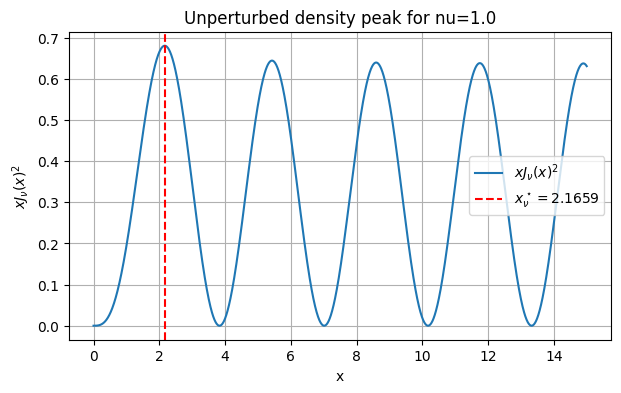

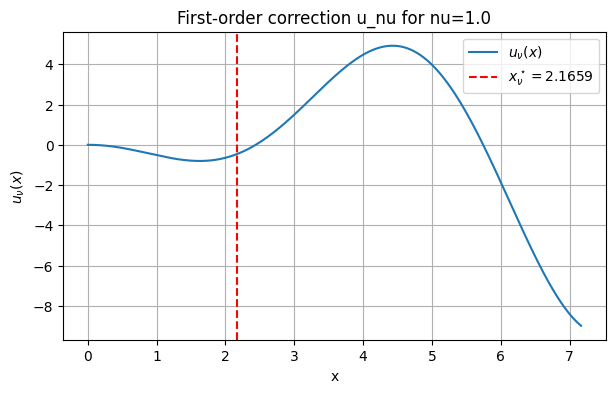

In [1]:
# ============================================
# Paper 37 coefficient extraction script
# Log-soft warp model / Paper 36 -> Paper 37
# ============================================

import numpy as np
import mpmath as mp
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

mp.mp.dps = 50  # high precision for mpmath

# -----------------------------
# Constants from earlier papers
# -----------------------------
b1 = 1.84118
b3 = 4.20119

# ---------------------------------------------------------
# Bessel J_nu and derivative using mpmath for robustness
# ---------------------------------------------------------
def J(nu, x):
    return float(mp.besselj(nu, x))

def Jp(nu, x):
    # J'_nu(x) = 1/2 [J_{nu-1}(x) - J_{nu+1}(x)]
    return 0.5 * (float(mp.besselj(nu - 1, x)) - float(mp.besselj(nu + 1, x)))

# ---------------------------------------------------------
# Unperturbed density and its derivatives
# rho0_tilde(x) = x J_nu(x)^2
# ---------------------------------------------------------
def rho0_tilde(nu, x):
    j = J(nu, x)
    return x * j * j

def rho0_prime(nu, x):
    j = J(nu, x)
    jp = Jp(nu, x)
    return j*j + 2*x*j*jp

def rho0_second_fd(nu, x, h=1e-5):
    # finite-difference second derivative
    return (rho0_tilde(nu, x+h) - 2*rho0_tilde(nu, x) + rho0_tilde(nu, x-h)) / (h*h)

# ---------------------------------------------------------
# Find first nontrivial local maximum of x J_nu(x)^2
# ---------------------------------------------------------
def find_peak_xstar(nu, x_min=1e-4, x_max=30.0, nscan=5000):
    xs = np.linspace(x_min, x_max, nscan)
    vals = np.array([rho0_prime(nu, x) for x in xs])

    candidates = []
    for i in range(len(xs)-1):
        if vals[i] == 0:
            xroot = xs[i]
        elif vals[i] * vals[i+1] < 0:
            try:
                sol = root_scalar(lambda x: rho0_prime(nu, x),
                                  bracket=[xs[i], xs[i+1]], method='brentq')
                xroot = sol.root
            except:
                continue
        else:
            continue

        second = rho0_second_fd(nu, xroot)
        if second < 0:
            candidates.append((xroot, second))

    if not candidates:
        raise RuntimeError(f"No peak root found for nu={nu}")

    # first local maximum
    xstar = sorted(candidates, key=lambda t: t[0])[0][0]
    return xstar

# ---------------------------------------------------------
# ODE for u_nu:
# u'' + (1/x) u' + (1 - nu^2/x^2) u = S(x)
# where S(x) = -4 J'_nu(x) + 2 x J_nu(x)
#
# Rewrite as:
# y1 = u
# y2 = u'
# y1' = y2
# y2' = S - (1/x) y2 - (1 - nu^2/x^2) y1
# ---------------------------------------------------------
def source_term(nu, x):
    return -4.0 * Jp(nu, x) + 2.0 * x * J(nu, x)

def ode_system(nu):
    def f(x, y):
        u, up = y
        s = source_term(nu, x)
        upp = s - (1.0/x)*up - (1.0 - (nu*nu)/(x*x))*u
        return [up, upp]
    return f

# ---------------------------------------------------------
# Regular initial data near origin
#
# Practical approach:
# choose regular branch only:
# u(x_min) = c_reg * x_min^nu
# u'(x_min)= c_reg * nu * x_min^(nu-1)
#
# Since the equation is inhomogeneous, we do a more stable
# split:
# u = u_part + c_reg * J_nu
#
# To avoid arbitrary homogeneous contamination, we set
# c_reg = 0 and start with very small values.
#
# For better stability, we can estimate a particular solution
# with Frobenius-like ansatz:
# u ~ A x^(nu+1) + B x^(nu+2) ...
# but to keep code robust, we use small regular start:
# u(x_min)=0, u'(x_min)=0
#
# Then we test stability by varying x_min.
# ---------------------------------------------------------
def solve_u(nu, x_end, x_min=1e-4, rtol=1e-9, atol=1e-11, dense=True):
    f = ode_system(nu)

    # Simple regular start
    y0 = [0.0, 0.0]

    sol = solve_ivp(
        f,
        (x_min, x_end),
        y0,
        method='DOP853',
        dense_output=dense,
        rtol=rtol,
        atol=atol,
        max_step=0.05
    )
    if not sol.success:
        raise RuntimeError(f"ODE solve failed for nu={nu}: {sol.message}")
    return sol

# ---------------------------------------------------------
# Compute chi_nu and kappa_nu
# chi_nu = - [ J(x*) u(x*) + 2 x* J(x*) u'(x*) ] / rho0''(x*)
#
# using simplified Paper 36 formula
# ---------------------------------------------------------
def compute_coefficients(nu, x_buffer=5.0, x_min=1e-4):
    xstar = find_peak_xstar(nu)
    x_end = xstar + x_buffer

    sol = solve_u(nu, x_end=x_end, x_min=x_min, dense=True)
    u_star, up_star = sol.sol(xstar)

    j_star = J(nu, xstar)
    denom = rho0_second_fd(nu, xstar)

    chi = - (j_star * u_star + 2.0 * xstar * j_star * up_star) / denom
    kappa = chi / xstar
    K13 = kappa * (1.0/b3 - 1.0/b1)

    return {
        "nu": nu,
        "xstar": xstar,
        "u_star": float(u_star),
        "up_star": float(up_star),
        "rho0_second": denom,
        "chi": chi,
        "kappa": kappa,
        "K13": K13,
        "solver": sol,
    }

# ---------------------------------------------------------
# Stability test by varying x_min
# ---------------------------------------------------------
def stability_test(nu, xmins=(1e-3, 5e-4, 1e-4, 5e-5)):
    results = []
    for xm in xmins:
        try:
            res = compute_coefficients(nu, x_min=xm)
            results.append((xm, res["chi"], res["kappa"], res["K13"]))
        except Exception as e:
            results.append((xm, str(e), None, None))
    return results

# ---------------------------------------------------------
# Pretty print
# ---------------------------------------------------------
def print_results(res):
    print(f"nu        = {res['nu']}")
    print(f"x*_nu     = {res['xstar']:.12f}")
    print(f"u(x*)     = {res['u_star']:.12e}")
    print(f"u'(x*)    = {res['up_star']:.12e}")
    print(f"rho0''    = {res['rho0_second']:.12e}")
    print(f"chi_nu    = {res['chi']:.12e}")
    print(f"kappa_nu  = {res['kappa']:.12e}")
    print(f"K13^(nu)  = {res['K13']:.12e}")

# ---------------------------------------------------------
# Plot helpers
# ---------------------------------------------------------
def plot_unperturbed_density(nu, x_max=15):
    xs = np.linspace(1e-4, x_max, 2000)
    ys = np.array([rho0_tilde(nu, x) for x in xs])
    xstar = find_peak_xstar(nu)

    plt.figure(figsize=(7,4))
    plt.plot(xs, ys, label=r"$xJ_\nu(x)^2$")
    plt.axvline(xstar, color='r', linestyle='--', label=fr"$x_\nu^\star={xstar:.4f}$")
    plt.xlabel("x")
    plt.ylabel(r"$xJ_\nu(x)^2$")
    plt.title(f"Unperturbed density peak for nu={nu}")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_u_solution(res, x_max=None):
    nu = res["nu"]
    sol = res["solver"]
    xstar = res["xstar"]
    if x_max is None:
        x_max = xstar + 5.0

    xs = np.linspace(sol.t[0], x_max, 1500)
    ys = sol.sol(xs)[0]

    plt.figure(figsize=(7,4))
    plt.plot(xs, ys, label=r"$u_\nu(x)$")
    plt.axvline(xstar, color='r', linestyle='--', label=fr"$x_\nu^\star={xstar:.4f}$")
    plt.xlabel("x")
    plt.ylabel(r"$u_\nu(x)$")
    plt.title(f"First-order correction u_nu for nu={nu}")
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------------------------------------------------
# Example runs
# ---------------------------------------------------------

# You should choose representative nu values relevant to your model.
# Here are examples:
nu_values = [0.5, 1.0, 1.5, 2.0]

all_results = []

for nu in nu_values:
    print("="*60)
    try:
        res = compute_coefficients(nu)
        print_results(res)
        all_results.append(res)
    except Exception as e:
        print(f"Failed for nu={nu}: {e}")

print("\nStability test example for nu=1.0")
stab = stability_test(1.0)
for row in stab:
    print(row)

# Example plots
plot_unperturbed_density(1.0)

res1 = compute_coefficients(1.0)
plot_u_solution(res1)

===== SERIES-INITIALIZED RESULTS =====
nu        = 0.5
mode      = series
x_min     = 1e-05
x*_nu     = 1.570796326795
u(x*)     = -3.210202555279e-01
u'(x*)    = 9.819785609965e-01
rho0''    = -1.273536831548e+00
chi_nu    = 1.381655588127e+00
kappa_nu  = 8.795892660040e-01
K13^(nu)  = -2.683645782730e-01
nu        = 1.0
mode      = series
x_min     = 1e-05
x*_nu     = 2.165871271488
u(x*)     = -4.621009166207e-01
u'(x*)    = 1.322491382131e+00
rho0''    = -1.143529715364e+00
chi_nu    = 2.581879991340e+00
kappa_nu  = 1.192074536159e+00
K13^(nu)  = -3.637045067862e-01
nu        = 1.5
mode      = series
x_min     = 1e-05
x*_nu     = 2.743707269992
u(x*)     = -3.485158455073e-01
u'(x*)    = 1.746581768218e+00
rho0''    = -1.056488230233e+00
chi_nu    = 4.476638772769e+00
kappa_nu  = 1.631602183560e+00
K13^(nu)  = -4.978053380411e-01
nu        = 2.0
mode      = series
x_min     = 1e-05
x*_nu     = 3.310753892095
u(x*)     = -5.196032160930e-02
u'(x*)    = 2.203690859590e+00
rho0''    =

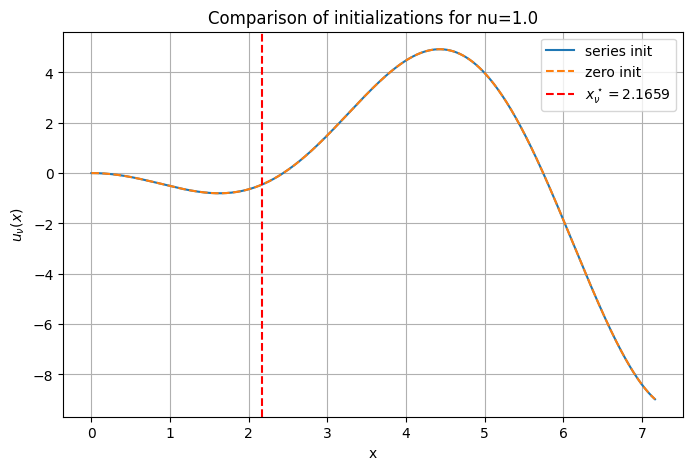

In [2]:
# ============================================
# Paper 37 coefficient extraction script
# Version 2: hardened origin initialization
# ============================================

import numpy as np
import mpmath as mp
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

mp.mp.dps = 60

b1 = 1.84118
b3 = 4.20119

# -----------------------------
# Bessel functions
# -----------------------------
def J(nu, x):
    return float(mp.besselj(nu, x))

def Jp(nu, x):
    return 0.5 * (float(mp.besselj(nu - 1, x)) - float(mp.besselj(nu + 1, x)))

# -----------------------------
# Unperturbed density
# -----------------------------
def rho0_tilde(nu, x):
    j = J(nu, x)
    return x * j * j

def rho0_prime(nu, x):
    j = J(nu, x)
    jp = Jp(nu, x)
    return j*j + 2*x*j*jp

def rho0_second_fd(nu, x, h=1e-6):
    return (rho0_tilde(nu, x+h) - 2*rho0_tilde(nu, x) + rho0_tilde(nu, x-h)) / (h*h)

# -----------------------------
# Find first peak
# -----------------------------
def find_peak_xstar(nu, x_min=1e-5, x_max=30.0, nscan=8000):
    xs = np.linspace(x_min, x_max, nscan)
    vals = np.array([rho0_prime(nu, x) for x in xs])

    candidates = []
    for i in range(len(xs)-1):
        if vals[i] * vals[i+1] < 0:
            sol = root_scalar(lambda x: rho0_prime(nu, x),
                              bracket=[xs[i], xs[i+1]], method='brentq')
            xroot = sol.root
            second = rho0_second_fd(nu, xroot)
            if second < 0:
                candidates.append((xroot, second))

    if not candidates:
        raise RuntimeError(f"No peak root found for nu={nu}")

    return sorted(candidates, key=lambda t: t[0])[0][0]

# -----------------------------
# Source term
# -----------------------------
def source_term(nu, x):
    return -4.0 * Jp(nu, x) + 2.0 * x * J(nu, x)

# -----------------------------
# ODE system
# -----------------------------
def ode_system(nu):
    def f(x, y):
        u, up = y
        s = source_term(nu, x)
        upp = s - (1.0/x)*up - (1.0 - (nu*nu)/(x*x))*u
        return [up, upp]
    return f

# -----------------------------
# Small-x regular series start
#
# We approximate u(x) = a x^nu + b x^(nu+1) + c x^(nu+2)
# and solve for coefficients by matching the ODE at very small x.
#
# To avoid symbolic complexity, we build a local numerical fit.
# -----------------------------
def regular_series_init(nu, x0):
    # We approximate the particular regular solution numerically.
    # Simpler but stronger than zero-start:
    #
    # use u = c2 x^(nu+2), since L[x^(nu+2)] gives x^nu-scale terms
    # matching the leading source behavior near origin.
    #
    # Derive leading source coefficient:
    # J_nu(x) ~ (x/2)^nu / Gamma(nu+1)
    # J'_nu(x) ~ nu/(2^(nu) Gamma(nu+1)) x^(nu-1)
    #
    # So source ~ -4 * const * x^(nu-1) + ...
    # and operator on x^(nu+1) also gives x^(nu-1), so use that.
    #
    # Let u = A x^(nu+1).
    # Then:
    # u'  = A (nu+1) x^nu
    # u'' = A (nu+1)nu x^(nu-1)
    #
    # L[u] = u'' + (1/x)u' + (1 - nu^2/x^2)u
    #      = A[(nu+1)nu + (nu+1) - nu^2] x^(nu-1) + A x^(nu+1)
    #      = A(2nu+1)x^(nu-1) + A x^(nu+1)
    #
    # Match leading source coefficient from -4 J'(x):
    leading_source = -4.0 * (nu / (2.0**nu * float(mp.gamma(nu+1))))
    A = leading_source / (2.0*nu + 1.0)

    u0 = A * x0**(nu+1)
    up0 = A * (nu+1) * x0**nu
    return u0, up0

# -----------------------------
# Solve with two initialization modes
# -----------------------------
def solve_u(nu, x_end, x_min=1e-5, mode="series", rtol=1e-10, atol=1e-12):
    f = ode_system(nu)

    if mode == "series":
        y0 = regular_series_init(nu, x_min)
    elif mode == "zero":
        y0 = [0.0, 0.0]
    else:
        raise ValueError("mode must be 'series' or 'zero'")

    sol = solve_ivp(
        f,
        (x_min, x_end),
        y0,
        method='DOP853',
        dense_output=True,
        rtol=rtol,
        atol=atol,
        max_step=0.03
    )
    if not sol.success:
        raise RuntimeError(f"ODE solve failed for nu={nu}: {sol.message}")
    return sol

# -----------------------------
# Compute coefficients
# -----------------------------
def compute_coefficients(nu, x_buffer=5.0, x_min=1e-5, mode="series"):
    xstar = find_peak_xstar(nu)
    x_end = xstar + x_buffer

    sol = solve_u(nu, x_end=x_end, x_min=x_min, mode=mode)
    u_star, up_star = sol.sol(xstar)

    j_star = J(nu, xstar)
    denom = rho0_second_fd(nu, xstar)

    chi = - (j_star * u_star + 2.0 * xstar * j_star * up_star) / denom
    kappa = chi / xstar
    K13 = kappa * (1.0/b3 - 1.0/b1)

    return {
        "nu": nu,
        "mode": mode,
        "x_min": x_min,
        "xstar": xstar,
        "u_star": float(u_star),
        "up_star": float(up_star),
        "rho0_second": float(denom),
        "chi": float(chi),
        "kappa": float(kappa),
        "K13": float(K13),
        "solver": sol,
    }

# -----------------------------
# Compare series-start and zero-start
# -----------------------------
def compare_initializations(nu, x_min=1e-5):
    res_series = compute_coefficients(nu, x_min=x_min, mode="series")
    res_zero   = compute_coefficients(nu, x_min=x_min, mode="zero")
    return res_series, res_zero

# -----------------------------
# Stability diagnostics
# -----------------------------
def stability_test(nu, xmins=(1e-3, 5e-4, 1e-4, 5e-5, 1e-5), mode="series"):
    rows = []
    for xm in xmins:
        try:
            r = compute_coefficients(nu, x_min=xm, mode=mode)
            rows.append((xm, r["chi"], r["kappa"], r["K13"]))
        except Exception as e:
            rows.append((xm, str(e), None, None))
    return rows

# -----------------------------
# Print helper
# -----------------------------
def print_results(res):
    print(f"nu        = {res['nu']}")
    print(f"mode      = {res['mode']}")
    print(f"x_min     = {res['x_min']}")
    print(f"x*_nu     = {res['xstar']:.12f}")
    print(f"u(x*)     = {res['u_star']:.12e}")
    print(f"u'(x*)    = {res['up_star']:.12e}")
    print(f"rho0''    = {res['rho0_second']:.12e}")
    print(f"chi_nu    = {res['chi']:.12e}")
    print(f"kappa_nu  = {res['kappa']:.12e}")
    print(f"K13^(nu)  = {res['K13']:.12e}")

# -----------------------------
# Plot compare u(x)
# -----------------------------
def plot_compare_u(nu, x_min=1e-5, x_buffer=5.0):
    rs = compute_coefficients(nu, x_min=x_min, mode="series")
    rz = compute_coefficients(nu, x_min=x_min, mode="zero")

    xstar = rs["xstar"]
    xmax = xstar + x_buffer
    xs = np.linspace(x_min, xmax, 2000)

    us = rs["solver"].sol(xs)[0]
    uz = rz["solver"].sol(xs)[0]

    plt.figure(figsize=(8,5))
    plt.plot(xs, us, label="series init")
    plt.plot(xs, uz, "--", label="zero init")
    plt.axvline(xstar, color='r', linestyle='--', label=fr"$x_\nu^\star={xstar:.4f}$")
    plt.xlabel("x")
    plt.ylabel(r"$u_\nu(x)$")
    plt.title(f"Comparison of initializations for nu={nu}")
    plt.legend()
    plt.grid(True)
    plt.show()

# -----------------------------
# Example runs
# -----------------------------
nu_values = [0.5, 1.0, 1.5, 2.0]

print("===== SERIES-INITIALIZED RESULTS =====")
series_results = []
for nu in nu_values:
    print("="*60)
    try:
        res = compute_coefficients(nu, mode="series")
        print_results(res)
        series_results.append(res)
    except Exception as e:
        print(f"Failed for nu={nu}: {e}")

print("\n===== ZERO vs SERIES comparison for nu=1.0 =====")
r_series, r_zero = compare_initializations(1.0)
print("\nSeries start:")
print_results(r_series)
print("\nZero start:")
print_results(r_zero)

print("\n===== Stability test (series mode) for nu=1.0 =====")
stab_series = stability_test(1.0, mode="series")
for row in stab_series:
    print(row)

plot_compare_u(1.0)

In [5]:
# ============================================
# Paper 37 coefficient extraction script
# Version 3: Green-function / variation-of-parameters cross-check
# (CORRECTED SIGN CONVENTION)
# ============================================

import numpy as np
import mpmath as mp
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

mp.mp.dps = 80

b1 = 1.84118
b3 = 4.20119

# -----------------------------
# Bessel functions
# -----------------------------
def J(nu, x):
    return mp.besselj(nu, x)

def Y(nu, x):
    return mp.bessely(nu, x)

def Jp(nu, x):
    return (mp.besselj(nu - 1, x) - mp.besselj(nu + 1, x)) / 2

def Yp(nu, x):
    return (mp.bessely(nu - 1, x) - mp.bessely(nu + 1, x)) / 2

# -----------------------------
# Source term
# -----------------------------
def source_term(nu, x):
    return -4 * Jp(nu, x) + 2 * x * J(nu, x)

# -----------------------------
# Density and peak location
# -----------------------------
def rho0_tilde(nu, x):
    return x * J(nu, x)**2

def rho0_prime(nu, x):
    return J(nu, x)**2 + 2*x*J(nu, x)*Jp(nu, x)

def rho0_second_fd(nu, x, h=1e-7):
    x = mp.mpf(x)
    h = mp.mpf(h)
    return (rho0_tilde(nu, x+h) - 2*rho0_tilde(nu, x) + rho0_tilde(nu, x-h)) / (h*h)

def find_peak_xstar(nu, x_min=1e-6, x_max=30.0, nscan=10000):
    xs = np.linspace(x_min, x_max, nscan)
    vals = np.array([float(rho0_prime(nu, x)) for x in xs])

    candidates = []
    for i in range(len(xs)-1):
        if vals[i] * vals[i+1] < 0:
            sol = root_scalar(lambda x: float(rho0_prime(nu, x)),
                              bracket=[xs[i], xs[i+1]], method='brentq')
            xr = sol.root
            second = float(rho0_second_fd(nu, xr))
            if second < 0:
                candidates.append((xr, second))

    if not candidates:
        raise RuntimeError(f"No peak root found for nu={nu}")

    return mp.mpf(sorted(candidates, key=lambda t: t[0])[0][0])

# -----------------------------
# Green-function regular solution
# CORRECTED: overall minus sign added to match ODE branch
# -----------------------------
def u_green(nu, x, eps=1e-6):
    x = mp.mpf(x)
    eps = mp.mpf(eps)

    if x <= eps:
        raise ValueError("x must be > eps")

    def integrand1(s):
        return s * Y(nu, s) * source_term(nu, s)

    def integrand2(s):
        return s * J(nu, s) * source_term(nu, s)

    I1 = mp.quad(integrand1, [eps, x])
    I2 = mp.quad(integrand2, [eps, x])

    # Overall minus sign inserted here
    return -(mp.pi/2) * (J(nu, x)*I1 - Y(nu, x)*I2)

def up_green(nu, x, eps=1e-6):
    x = mp.mpf(x)
    eps = mp.mpf(eps)

    def integrand1(s):
        return s * Y(nu, s) * source_term(nu, s)

    def integrand2(s):
        return s * J(nu, s) * source_term(nu, s)

    I1 = mp.quad(integrand1, [eps, x])
    I2 = mp.quad(integrand2, [eps, x])

    # Overall minus sign inserted here
    return -(mp.pi/2) * (Jp(nu, x)*I1 - Yp(nu, x)*I2)

# -----------------------------
# Coefficient extraction via Green function
# -----------------------------
def compute_coefficients_green(nu, eps=1e-6):
    xstar = find_peak_xstar(nu)

    u_star = u_green(nu, xstar, eps=eps)
    up_star = up_green(nu, xstar, eps=eps)

    j_star = J(nu, xstar)
    denom = rho0_second_fd(nu, xstar)

    chi = - (j_star*u_star + 2*xstar*j_star*up_star) / denom
    kappa = chi / xstar
    K13 = kappa * (1/mp.mpf(b3) - 1/mp.mpf(b1))

    return {
        "nu": float(nu),
        "eps": float(eps),
        "xstar": float(xstar),
        "u_star": float(u_star),
        "up_star": float(up_star),
        "rho0_second": float(denom),
        "chi": float(chi),
        "kappa": float(kappa),
        "K13": float(K13),
    }

# -----------------------------
# epsilon stability test
# -----------------------------
def epsilon_stability_test(nu, eps_values=(1e-3, 1e-4, 1e-5, 1e-6)):
    rows = []
    for eps in eps_values:
        try:
            r = compute_coefficients_green(nu, eps=eps)
            rows.append((eps, r["chi"], r["kappa"], r["K13"]))
        except Exception as e:
            rows.append((eps, str(e), None, None))
    return rows

# -----------------------------
# ODE reference from Version 2 results
# -----------------------------
ode_reference = {
    0.5: {"chi": 1.381655588127, "kappa": 0.8795892660040, "K13": -0.2683645782730},
    1.0: {"chi": 2.581879991340, "kappa": 1.192074536159, "K13": -0.3637045067862},
    1.5: {"chi": 4.476638772769, "kappa": 1.631602183560, "K13": -0.4978053380411},
    2.0: {"chi": 6.992393332686, "kappa": 2.112024499731, "K13": -0.6443832207590},
}

def compare_with_ode(nu, eps=1e-6):
    g = compute_coefficients_green(nu, eps=eps)
    o = ode_reference[nu]
    print(f"nu = {nu}, eps = {eps}")
    print(f"Green chi   = {g['chi']:.12f}   | ODE chi   = {o['chi']:.12f}   | diff = {g['chi'] - o['chi']:.3e}")
    print(f"Green kappa = {g['kappa']:.12f} | ODE kappa = {o['kappa']:.12f} | diff = {g['kappa'] - o['kappa']:.3e}")
    print(f"Green K13   = {g['K13']:.12f}   | ODE K13   = {o['K13']:.12f}   | diff = {g['K13'] - o['K13']:.3e}")

# -----------------------------
# Main Execution
# -----------------------------
nu_values = [0.5, 1.0, 1.5, 2.0]

print("===== CORRECTED GREEN-FUNCTION RESULTS =====")
for nu in nu_values:
    print("="*60)
    try:
        r = compute_coefficients_green(nu, eps=1e-6)
        for k, v in r.items():
            print(f"{k:12s} = {v}")
    except Exception as e:
        print(f"Failed for nu={nu}: {e}")

print("\n===== Epsilon stability test for nu=1.0 =====")
for row in epsilon_stability_test(1.0):
    print(row)

print("\n===== Comparison: Green vs ODE =====")
for nu in nu_values:
    compare_with_ode(nu, eps=1e-6)
    print("-"*60)

===== CORRECTED GREEN-FUNCTION RESULTS =====
nu           = 0.5
eps          = 1e-06
xstar        = 1.5707963267948972
u_star       = -0.3210189822882874
up_star      = 0.9819781557123738
rho0_second  = -1.2732395447351585
chi          = 1.3819781888416849
kappa        = 0.8797946399973555
K13          = -0.26842723832045656
nu           = 1.0
eps          = 1e-06
xstar        = 2.165871271488751
u_star       = -0.4620997954182227
up_star      = 1.3224911232979981
rho0_second  = -1.1436980831310608
chi          = 2.5814999038217046
kappa        = 1.1918990467274002
K13          = -0.363650964582806
nu           = 1.5
eps          = 1e-06
xstar        = 2.7437072699926497
u_star       = -0.3485148213253333
up_star      = 1.7465815815773698
rho0_second  = -1.0566917058077678
chi          = 4.475776755363454
kappa        = 1.6312880037583033
K13          = -0.4977094811073731
nu           = 2.0
eps          = 1e-06
xstar        = 3.3107538920956823
u_star       = -0.051959367043041105
up_